In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score , silhouette_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [42]:
df = pd.read_csv('Country-data.csv')

In [43]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [44]:
df.shape

(167, 10)

In [45]:
# DATA CLEANING 
df.columns = df.columns.str.strip()

In [46]:
df.drop_duplicates(inplace = True)

In [47]:
country_names = df['country']
X = df.drop("country" , axis = 1)

for col in X.columns : 
    X[col] = pd.to_numeric(X[col] , errors = "coerce")

X.fillna(X.median(numeric_only=True) , inplace = True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [48]:
print("Missing values : ")
print(X.isnull().sum())

Missing values : 
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [49]:
# FEATURE SCALING

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 1.29153238 -1.13827979  0.27908825 ... -1.61909203  1.90288227
  -0.67917961]
 [-0.5389489  -0.47965843 -0.09701618 ...  0.64786643 -0.85997281
  -0.48562324]
 [-0.27283273 -0.09912164 -0.96607302 ...  0.67042323 -0.0384044
  -0.46537561]
 ...
 [-0.37231541  1.13030491  0.0088773  ...  0.28695762 -0.66120626
  -0.63775406]
 [ 0.44841668 -0.40647827 -0.59727159 ... -0.34463279  1.14094382
  -0.63775406]
 [ 1.11495062 -0.15034774 -0.33801514 ... -2.09278484  1.6246091
  -0.62954556]]


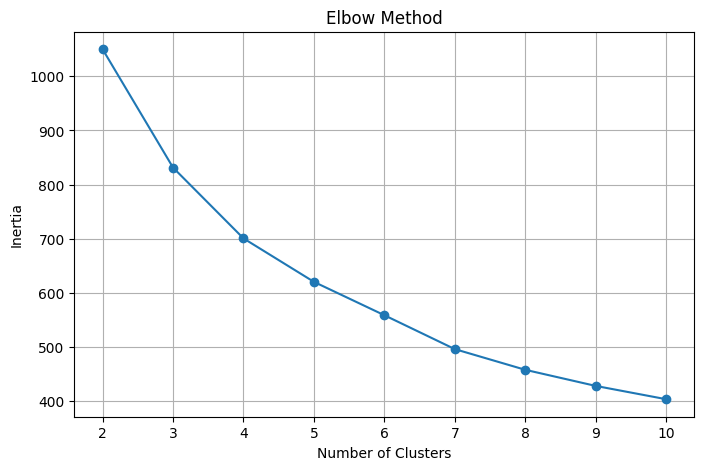

In [50]:
# ELBOW METHOD : used to find the cluster values 
interia = [] 

for k in range(2 , 11) :
    model = KMeans(
        n_clusters=k , 
        random_state = 42 , 
        n_init = 10
    )

    model.fit(X_scaled)

    interia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), interia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [51]:
# K-MEANS

best_k = 3 

kmeans = KMeans(
    n_clusters=best_k , 
    random_state = 42 , 
    n_init = 10 
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = kmeans_labels

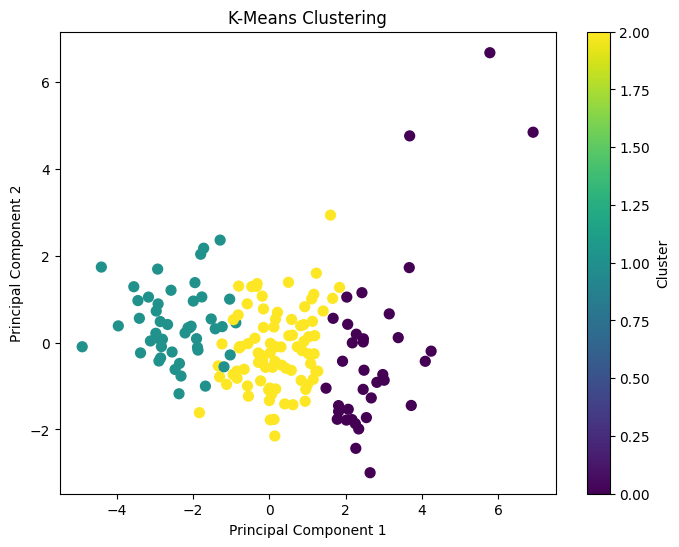

In [52]:
# KMEANS ON GRAPH(PLOTTING)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

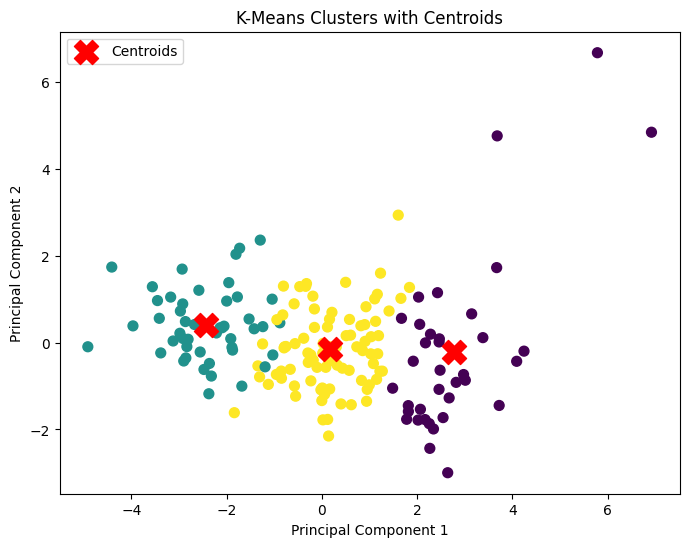

In [53]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=50
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=300,
    c='red',
    label='Centroids'
)

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [54]:
# SILHOUETTE SCORE

sil_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.2833


In [55]:
# SUMMARAY

cluster_summary = (
    df.groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

print("\nCluster Summary")
print(cluster_summary)


Cluster Summary
         child_mort  exports  health  imports    income  inflation  \
Cluster                                                              
0              5.00    58.74    8.81    51.49  45672.22       2.67   
1             92.96    29.15    6.39    42.32   3942.40      12.02   
2             21.93    40.24    6.20    47.47  12305.60       7.60   

         life_expec  total_fer      gdpp  
Cluster                                   
0             80.13       1.75  42494.44  
1             59.19       5.01   1922.38  
2             72.81       2.31   6486.45  


In [56]:
# DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

clusters_found = len(set(dbscan_labels))

if -1 in dbscan_labels:
    clusters_found -= 1

print("DBSCAN RESULTS")

print("Clusters Found:", clusters_found)

print(
    "Noise Points:", np.sum(dbscan_labels == -1)
)


DBSCAN RESULTS
Clusters Found: 1
Noise Points: 30


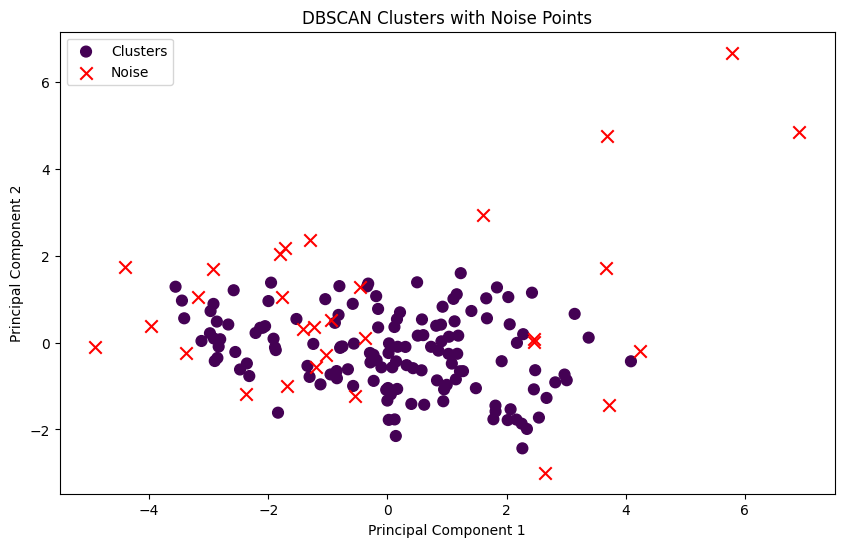

In [57]:
# DBSCAN GRAPH(PLOTTING)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

noise_mask = dbscan_labels == -1

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[~noise_mask, 0],
    X_pca[~noise_mask, 1],
    c=dbscan_labels[~noise_mask],
    cmap='viridis',
    s=60,
    label='Clusters'
)

plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c='red',
    s=80,
    marker='x',
    label='Noise'
)

plt.title("DBSCAN Clusters with Noise Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [58]:
# RANDOM FOREST 

y = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled ,y , test_size=0.2 , random_state=42 , stratify=y
)

rf = RandomForestClassifier(n_estimators=200 , random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RANDOM FOREST RESULTS")

print("Accuracy : " , round(accuracy_score(y_test, rf_pred) , 4))
print("Precision : " , round(precision_score(y_test , rf_pred , average="weighted"),4))
print("Recall : " , round(recall_score(y_test , rf_pred , average="weighted") , 4))
print("F1 Score : " , round(f1_score(y_test , rf_pred , average="weighted") , 4))

print("Classifivation Report")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS
Accuracy :  1.0
Precision :  1.0
Recall :  1.0
F1 Score :  1.0
Classifivation Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [59]:
# XGBOOST 

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBOOST RESULTS")

print("Accuracy : " , round(accuracy_score(y_test , xgb_pred) , 4))
print("Precision : " , round(precision_score(y_test , xgb_pred , average="weighted"),4))
print("Recall : " , round(recall_score(y_test , xgb_pred , average="weighted") , 4))
print("F1 Score : " , round(f1_score(y_test , xgb_pred , average="weighted") , 4))

print("classification_report ")
print(classification_report(y_test, xgb_pred))


XGBOOST RESULTS
Accuracy :  0.9706
Precision :  0.9722
Recall :  0.9706
F1 Score :  0.9702
classification_report 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



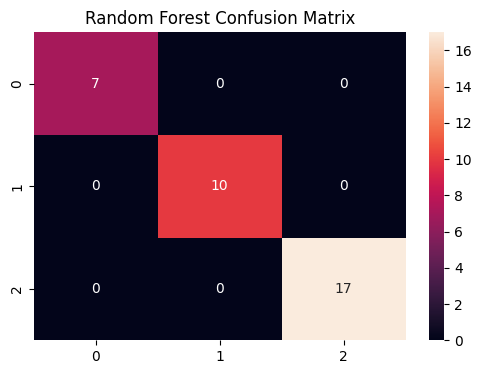

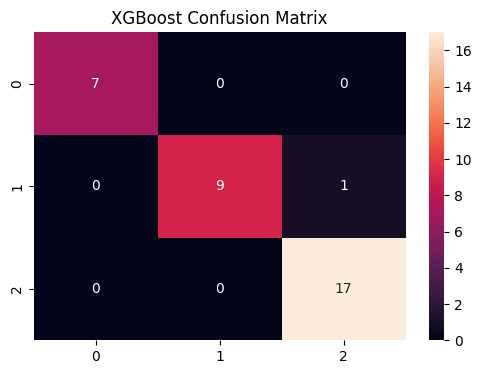

In [60]:
# CONFUSION MATRIX 

plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, rf_pred) , annot=True , fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, xgb_pred) , annot=True , fmt='d')

plt.title("XGBoost Confusion Matrix")
plt.show()

In [61]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top Important Features")
print(importance.head(10))

Top Important Features
      Feature  Importance
0  child_mort    0.261935
8        gdpp    0.202125
7   total_fer    0.165920
6  life_expec    0.156307
4      income    0.146203
2      health    0.030472
5   inflation    0.014817
3     imports    0.012632
1     exports    0.009589


In [62]:
summary = df.groupby("Cluster").mean(numeric_only=True)

high_mortality_cluster = summary["child_mort"].idxmax()

best_economy_cluster = summary["gdpp"].idxmax()

low_development_cluster = summary["gdpp"].idxmin()

In [63]:
print(f"1. Cluster {high_mortality_cluster} has the highest child mortality rate and represents countries facing major development and healthcare challenges.")

print(f"2. Cluster {best_economy_cluster} has the highest GDP per capita and income levels, indicating the most economically advanced nations.")

print(f"3. Cluster {low_development_cluster} has the lowest GDP levels and weaker socio-economic indicators, representing underdeveloped regions.")

print("4. Countries with higher income generally exhibit higher life expectancy and lower child mortality.")

print("5. K-Means produced well-separated clusters as indicated by the silhouette score and PCA visualization.")

print("6. Random Forest and XGBoost achieved strong classification performance, demonstrating that country segments are highly distinguishable.")

1. Cluster 1 has the highest child mortality rate and represents countries facing major development and healthcare challenges.
2. Cluster 0 has the highest GDP per capita and income levels, indicating the most economically advanced nations.
3. Cluster 1 has the lowest GDP levels and weaker socio-economic indicators, representing underdeveloped regions.
4. Countries with higher income generally exhibit higher life expectancy and lower child mortality.
5. K-Means produced well-separated clusters as indicated by the silhouette score and PCA visualization.
6. Random Forest and XGBoost achieved strong classification performance, demonstrating that country segments are highly distinguishable.
